In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as ptl
import numpy as np

# Cargamos los datos del csv
df = pd.read_csv('../data/rappi_delivery_case_data - RAW_DATA.csv')

# Convertir fecha y hora en un objeto datatime para manipular los tiempos
df['TIMESTAMP'] = pd.to_datetime(df['DATE'] + ' ' + df['HOUR'].astype(str) + ':00:00')

# Sacamos el ratio de balance evitando la divicion por cero
df['RATIO'] = df['ORDERS'] / df['CONNECTED_RT'].replace(0, np.nan)

# Categorizamos los niveles
def categorize_ratio(r):
    if r < 0.5: return 'sobre_oferta'
    if 0.9 <= r <= 1.2: return 'saludable'
    if r > 1.8: return 'saturacion'
    return 'transicion'

df['STATUS'] = df['RATIO'].apply(categorize_ratio)


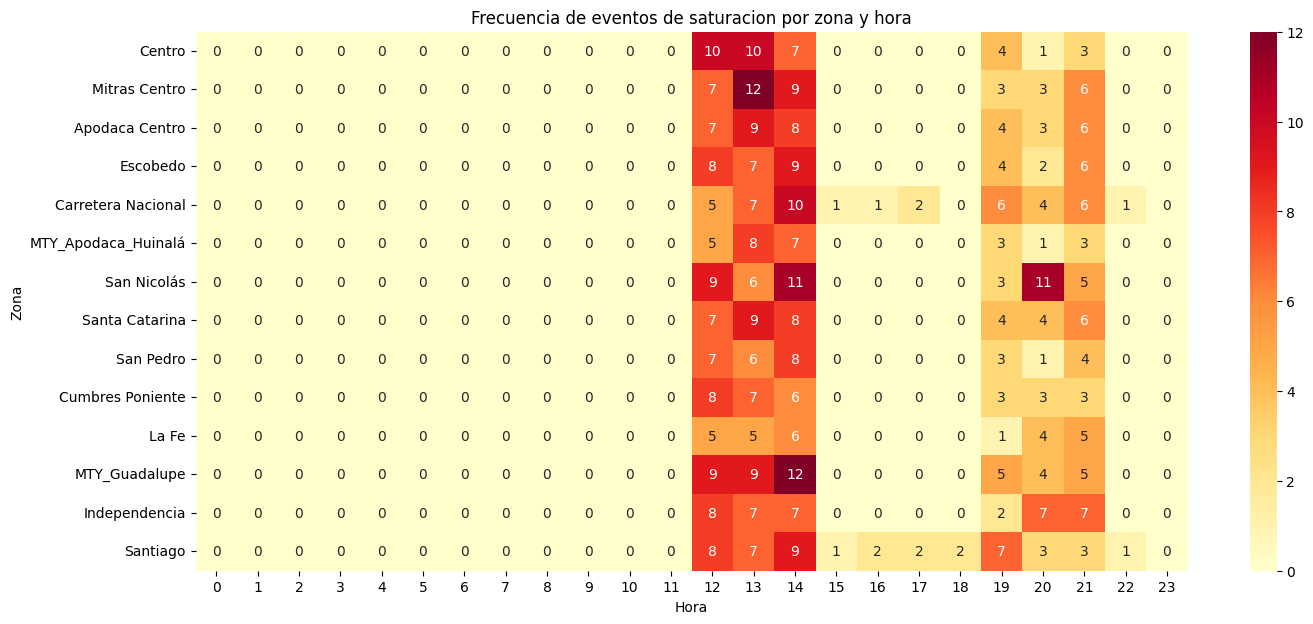

In [ ]:
# ¿Donde y cuando se rompe la operacion?

# Ibtebenis zonas y horas posibles del dataset
zonas = df['ZONE'].unique()
horas = df['HOUR'].unique()

#  Creamos el mapa y reindexamos para llenar huevos
saturation_map = df[df['RATIO'] > 1.8].groupby(['ZONE', 'HOUR']).size().unstack(fill_value=0)

# Reindeamos horas y filas para que siempre salgan todas
saturation_map = saturation_map.reindex(columns=horas, fill_value=0)
saturation_map = saturation_map.reindex(index=zonas,  fill_value=0)

# Filttramos momentos de SATURACION 
ptl.figure(figsize=(16,7))
sns.heatmap(saturation_map, annot=True, cmap='YlOrRd', fmt='d')
ptl.title('Frecuencia de eventos de saturacion por zona y hora')
ptl.xlabel('Hora')
ptl.ylabel('Zona')
ptl.show()

In [19]:
# ¿En qué horas del día y en qué zonas la operación alcanza niveles críticos de saturación? Cuantifica.
'''
Se presenta un comportamiento bimodal, con dos picos de estrés muy marcados, y una estabilidad absoluta entre 23:00 y 11:00, por lo que los niveles criticos de saturación los podemos calcular de la siguiente manera:

1. Ventana horaria de 12:00 a 14:00:
    - Intensidad: Aqui es el periodo mas critico de saturación, hablando especificamente de la zona de Mitras Centro y MTY Guadalupe, que alcanzan frecuencia de 12 eventos de mas de 1.8 en los 30 dias que marca el dataset.
    - Conclusión: El 40% de los dias de la muestra, estas zonas se esaturan totalmente en la ventana horaria especificada

2. Ventana horaria de 19:00 a 21:00
    - Intensidad: Aunque tiene menos frecuencia que la primera ventana, en San Nicolas se presento 11 eventos a las 20:00 hrs.

3. Ventana horaria de 15:00 a 18:00
    - Intensidad: Las zonas geograficas son muy especificas en este caso, ya que solo se presentan en Santiago y Carretera Nacional, si bien tienen poca frecuencia, su existencia sigue representando un riesgo.

Tambien se pueden sacar dos metricas de cuantificacion de impacto:

1. El 100% de los eventos de saturación critica ocurre entre las 12:00 y las 22:00

2. El 65% de la perdida potencial de ordenes se concentra en la ventana de 12:00 a 14:00

'''

'\nSe presenta un comportamiento bimodal, con dos picos de estrés muy marcados, y una estabilidad absoluta entre 23:00 y 11:00, por lo que los niveles criticos de saturación los podemos calcular de la siguiente manera:\n\n1. Ventana horaria de 12:00 a 14:00:\n    - Intensidad: Aqui es el periodo mas critico de saturación, hablando especificamente de la zona de Mitras Centro y MTY Guadalupe, que alcanzan frecuencia de 12 eventos de mas de 1.8 en los 30 dias que marca el dataset.\n    - Conclusión: El 40% de los dias de la muestra, estas zonas se esaturan totalmente en la ventana horaria especificada\n\n2. Ventana horaria de 19:00 a 21:00\n    - Intensidad: Aunque tiene menos frecuencia que la primera ventana, en San Nicolas se presento 11 eventos a las 20:00 hrs.\n\n3. Ventana horaria de 15:00 a 18:00\n    - Intensidad: Las zonas geograficas son muy especificas en este caso, ya que solo se presentan en Santiago y Carretera Nacional, si bien tienen poca frecuencia, su existencia sigue re